In [1]:
import pandas as pd;
import numpy as np;
import seaborn as sns;
import matplotlib.pyplot as plt;
# Import necessary libraries for data manipulation, numerical operations, and visualization

In [2]:
# Load the Diabetes dataset from a remote URL and display the first 5 rows
df=pd.read_csv("https://raw.githubusercontent.com/Kirisaki00/Principal_Component_Analysis_On_Diabetes_Dataset/refs/heads/main/diabetes.csv");
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Check for missing values in the dataset
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [4]:
# Calculate the correlation matrix to understand relationships between features
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [6]:
# Get statistical summary of the raw data (transposed for better readability)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [9]:
# Remove the target variable 'Outcome' to perform unsupervised learning (PCA)
df.drop(columns=["Outcome"], axis=1, inplace=True);

In [10]:
# Standardize the features so they have a mean of 0 and variance of 1
from sklearn.preprocessing import StandardScaler;
scaler=StandardScaler();
scaled_df=scaler.fit_transform(df);

In [11]:
# Convert the scaled array back into a DataFrame and verify the transformation
df=pd.DataFrame(scaled_df, columns=df.columns);
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.848324,0.149641,0.907270,-0.692891,0.204013,0.468492,1.425995
1,-0.844885,-1.123396,-0.160546,0.530902,-0.692891,-0.684422,-0.365061,-0.190672
2,1.233880,1.943724,-0.263941,-1.288212,-0.692891,-1.103255,0.604397,-0.105584
3,-0.844885,-0.998208,-0.160546,0.154533,0.123302,-0.494043,-0.920763,-1.041549
4,-1.141852,0.504055,-1.504687,0.907270,0.765836,1.409746,5.484909,-0.020496


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,-6.476301e-17,1.000652,-1.141852,-0.844885,-0.250952,0.639947,3.906578
Glucose,768.0,-9.251859e-18,1.000652,-3.783654,-0.685236,-0.121888,0.605771,2.444478
BloodPressure,768.0,1.503427e-17,1.000652,-3.572597,-0.367337,0.149641,0.563223,2.734528
SkinThickness,768.0,1.006140e-16,1.000652,-1.288212,-1.288212,0.154533,0.719086,4.921866
Insulin,768.0,-3.006854e-17,1.000652,-0.692891,-0.692891,-0.428062,0.412008,6.652839
BMI,768.0,2.590520e-16,1.000652,-4.060474,-0.595578,0.000942,0.584771,4.455807
DiabetesPedigreeFunction,768.0,2.451743e-16,1.000652,-1.189553,-0.688969,-0.300128,0.466227,5.883565
Age,768.0,1.931325e-16,1.000652,-1.041549,-0.786286,-0.360847,0.660206,4.063716


In [14]:
df.shape

(768, 8)

In [15]:
# Manually calculate the covariance matrix using matrix multiplication
covarianceMatrix=df.T @ df/767;
covarianceMatrix

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Pregnancies,1.001304,0.129627,0.141466,-0.081778,-0.073630,0.017706,-0.033566,0.545051
Glucose,0.129627,1.001304,0.152789,0.057403,0.331789,0.221359,0.137516,0.263858
BloodPressure,0.141466,0.152789,1.001304,0.207641,0.089049,0.282173,0.041319,0.239840
SkinThickness,-0.081778,0.057403,0.207641,1.001304,0.437352,0.393085,0.184167,-0.114119
Insulin,-0.073630,0.331789,0.089049,0.437352,1.001304,0.198117,0.185312,-0.042218
BMI,0.017706,0.221359,0.282173,0.393085,0.198117,1.001304,0.140830,0.036289
DiabetesPedigreeFunction,-0.033566,0.137516,0.041319,0.184167,0.185312,0.140830,1.001304,0.033605
Age,0.545051,0.263858,0.239840,-0.114119,-0.042218,0.036289,0.033605,1.001304


In [16]:
# Compute the eigenvalues and eigenvectors from the covariance matrix
eigValues, eigVector=np.linalg.eig(covarianceMatrix);

In [17]:
eigValues

array([2.09711056, 1.73346726, 0.42036353, 0.40498938, 0.68351839,
       0.76333832, 0.87667054, 1.03097228])

In [18]:
eigVector

array([[-0.1284321 , -0.59378583, -0.58879003,  0.11784098, -0.19359817,
         0.47560573, -0.08069115,  0.01308692],
       [-0.39308257, -0.17402908, -0.06015291,  0.45035526, -0.09416176,
        -0.46632804,  0.40432871, -0.46792282],
       [-0.36000261, -0.18389207, -0.19211793, -0.01129554,  0.6341159 ,
        -0.32795306, -0.05598649,  0.53549442],
       [-0.43982428,  0.33196534,  0.28221253,  0.5662838 , -0.00958944,
         0.48786206, -0.03797608,  0.2376738 ],
       [-0.43502617,  0.25078106, -0.13200992, -0.54862138,  0.27065061,
         0.34693481,  0.34994376, -0.33670893],
       [-0.45194134,  0.1009598 , -0.03536644, -0.34151764, -0.68537218,
        -0.25320376, -0.05364595,  0.36186463],
       [-0.27061144,  0.122069  , -0.08609107, -0.00825873,  0.08578409,
        -0.11981049, -0.8336801 , -0.43318905],
       [-0.19802707, -0.62058853,  0.71208542, -0.21166198,  0.03335717,
         0.10928996, -0.0712006 , -0.07524755]])

In [20]:
# Manually project the data onto the first Principal Component (PC1)
PC1_data=df @ eigVector[:,0];
PC1_data

,0
0,-1.068503
1,1.121683
2,0.396477
3,1.115781
4,-2.359334
...,...
763,-1.562085
764,0.100405
765,0.283475
766,1.060324


In [21]:
PC2_data=df@eigVector[:,1];
PC2_data

,0
0,-1.234895
1,0.733852
2,-1.595876
3,1.271241
4,2.184819
...,...
763,-1.923150
764,0.614181
765,-0.097065
766,-0.837062


In [22]:
PC3_data=df@eigVector[:,7];
PC3_data

,0
0,-0.095930
1,0.712938
2,-1.760678
3,0.663729
4,-2.963107
...,...
763,0.867408
764,0.764353
765,0.077192
766,-0.425030


In [24]:
# Use Scikit-Learn's PCA to transform the data into 2 dimensions
from sklearn.decomposition import PCA;
pca=PCA(n_components=2);
pca.fit_transform(df)

array([[ 1.06850273,  1.23489499],
       [-1.12168331, -0.73385167],
       [-0.39647671,  1.59587594],
       ...,
       [-0.28347525,  0.09706503],
       [-1.06032431,  0.83706234],
       [-0.83989172, -1.15175485]])

In [25]:
pca=PCA();
principalComponent=pca.fit_transform(df);
principalComponent

array([[ 1.06850273,  1.23489499, -0.09592984, ...,  0.35718251,
         0.85882133,  0.97430355],
       [-1.12168331, -0.73385167,  0.71293816, ..., -0.40632934,
         0.75703403,  0.35421454],
       [-0.39647671,  1.59587594, -1.76067844, ..., -0.04001752,
        -1.15299029,  1.06852795],
       ...,
       [-0.28347525,  0.09706503,  0.07719194, ..., -0.53826993,
        -0.33556321,  0.2894389 ],
       [-1.06032431,  0.83706234, -0.42503045, ...,  0.15330712,
         1.18030813, -0.53434386],
       [-0.83989172, -1.15175485,  1.00917817, ..., -0.15009639,
         0.24523536,  0.51594622]])

In [26]:
# Examine the percentage of variance explained by each principal component
pca.explained_variance_ratio_

array([0.26179749, 0.21640127, 0.12870373, 0.10944113, 0.09529305,
       0.08532855, 0.05247702, 0.05055776])

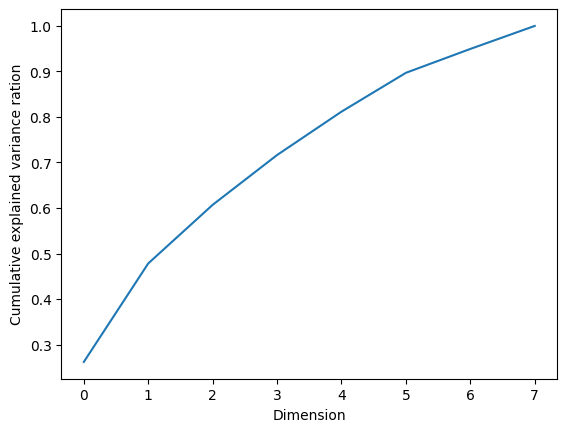

In [27]:
# Plot the cumulative explained variance to determine the optimal number of dimensions
plt.plot(np.cumsum(pca.explained_variance_ratio_));
plt.xlabel("Dimension");
plt.ylabel("Cumulative explained variance ratio");
plt.show()